# Retail Sales & Customer Behavior Analysis

## Objective
The goal of this project is to analyze retail transaction data to generate business insights related to:

- Sales performance
- Customer purchasing behavior
- Country-wise revenue contribution
- Product demand patterns
- Seasonal trends

These insights can help business stakeholders:
- Identify top performing products
- Understand customer purchasing trends
- Optimize inventory planning
- Focus marketing on high-value customers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the Dataset
The dataset contains transactional data for an online retail store including invoices, products, quantities, and customer details.

In [2]:
df = pd.read_csv("input_data/data.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Dataset Overview

The dataset contains the following fields:

- **InvoiceNo** – Invoice number for the transaction
- **StockCode** – Product code
- **Description** – Product description
- **Quantity** – Number of products purchased
- **InvoiceDate** – Date and time of transaction
- **UnitPrice** – Price per unit
- **CustomerID** – Unique customer identifier
- **Country** – Country where customer resides

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

Common issues in transactional datasets include:

- Missing customer IDs
- Cancelled orders
- Negative quantities (returns)
- Duplicate entries

These issues must be handled before analysis.

In [4]:
# Check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [6]:
# Remove cancelled transactions (Invoice starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [7]:
# Remove negative quantities
df = df[df['Quantity'] > 0]

## Feature Engineering

New variables are created to help with analysis.

**Revenue** = Quantity × UnitPrice

In [8]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


## Total Revenue Generated

In [9]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", round(total_revenue,2))

Total Revenue: 8911407.9


## Top Selling Products

Identifying the most sold products helps understand demand and inventory planning.

In [10]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

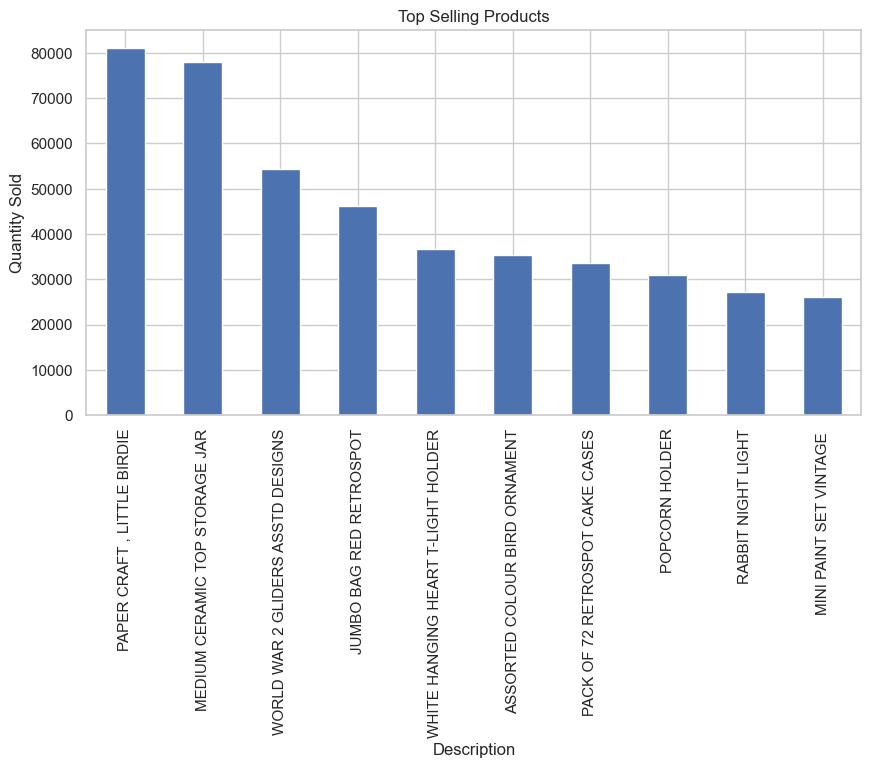

In [11]:
top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

## Revenue Contribution by Country

This helps identify the most valuable geographic markets.

In [12]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_sales

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

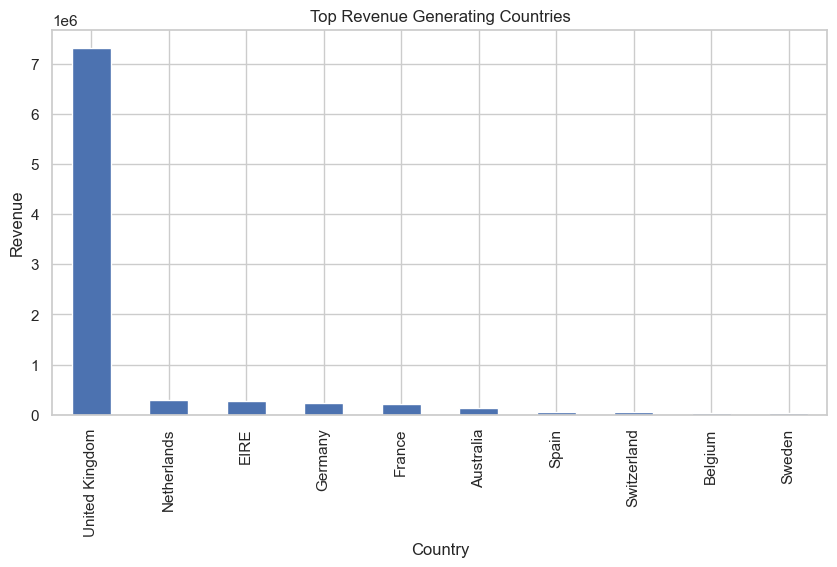

In [13]:
country_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top Revenue Generating Countries")
plt.ylabel("Revenue")
plt.show()

## Monthly Revenue Trend

Understanding seasonality helps businesses plan promotions and inventory.

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

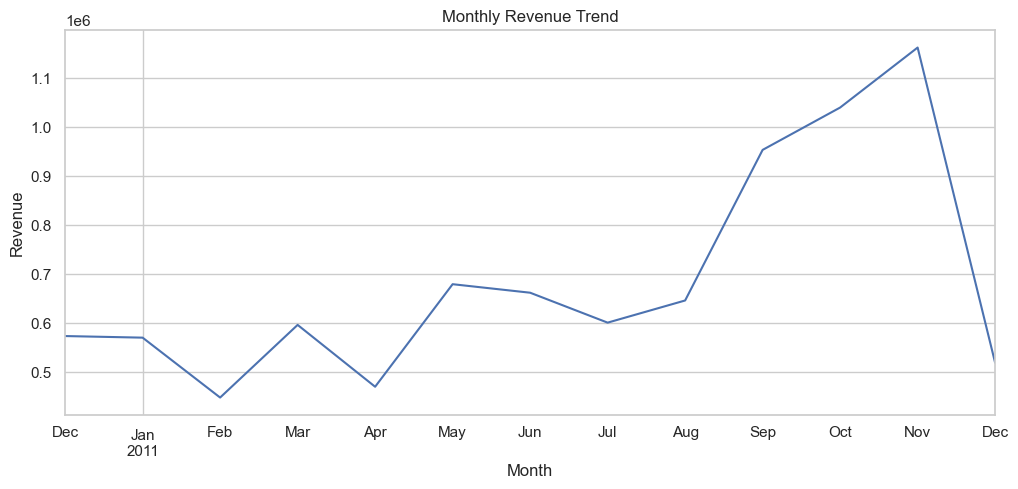

In [15]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

## High Value Customers

Identifying top customers helps businesses design loyalty programs and targeted marketing strategies.

In [16]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

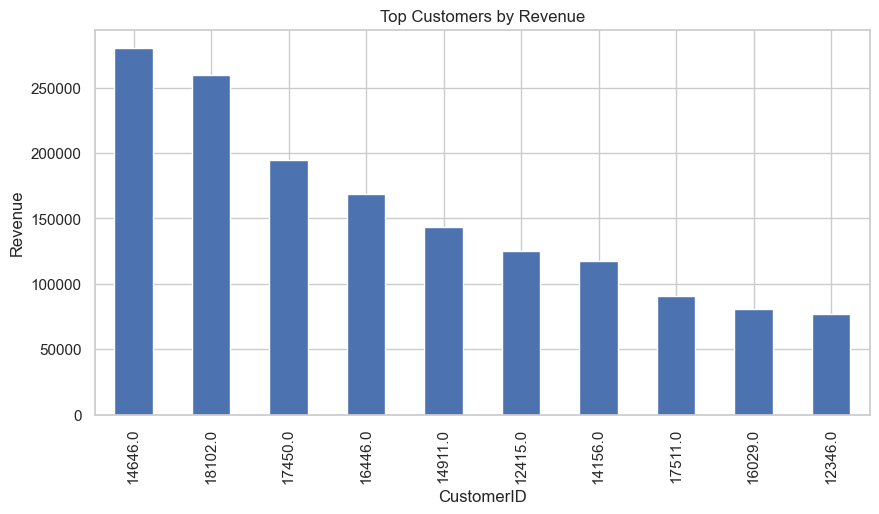

In [17]:
top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top Customers by Revenue")
plt.ylabel("Revenue")
plt.show()

## Key Insights

1. A small number of products generate a large portion of sales.
2. Certain countries contribute significantly more revenue than others.
3. Sales show monthly fluctuations indicating seasonal demand.
4. A small group of customers accounts for a large share of revenue.

## Business Recommendations

- Focus marketing campaigns on high-revenue countries.
- Maintain sufficient stock for top-selling products.
- Offer loyalty rewards to top customers.
- Use seasonal trends to plan inventory and promotions.

## Conclusion

This analysis provided insights into product demand, customer purchasing behavior, and revenue trends.

Such insights enable businesses to make data-driven decisions regarding:

- Inventory management
- Customer retention strategies
- Market expansion
- Sales forecasting

#Exporting the cleaned Data

In [19]:
df.to_csv("input_data/cleaned_data.csv")

In [23]:
import pymysql
from sqlalchemy import create_engine

In [26]:
username = "root"
password = "12345678"
host = "localhost"
port = 3306
database = "customer_segmentation"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df.to_sql("invoices", engine, if_exists="replace", index=False)


397924

In [27]:
pd.read_sql("SELECT * FROM invoices LIMIT 5;", engine)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
